### **Linear SVM-based classification with n-grams**

This notebook implements a text classification baseline using a Linear Support Vector Machine (LinearSVC) and TFIDF vectorization. To identify the most robust linguistic representation, we compare various feature extraction strategies, including raw word forms, normalized lemmas, POS tags, and character ngrams, using 5 fold Cross Validation on the training data. The best performing configuration is then retrained on the full training set and evaluated on the unseen Validation and Test sets. Finally, we assess the model's overall discriminative power and reliability through visual diagnostics, such as Confusion Matrices, ROC curves, and Precision Recall curves.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import hinge_loss, f1_score

from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

### Data loading

In [2]:
# Load the processed dataframes using the correct paths
df_train = pd.read_pickle("../data/enriched/train_final.pkl")
df_val = pd.read_pickle("../data/enriched/val_final.pkl")  
df_test = pd.read_pickle("../data/enriched/test_final.pkl")

# Extract the target vectors
y_train = df_train['label'].copy()
y_val = df_val['label'].copy()
y_test = df_test['label'].copy()

print(f"Train shape: {df_train.shape}")
print(f"Validation shape: {df_val.shape}")
print(f"Test shape: {df_test.shape}\n")

Train shape: (4000, 147)
Validation shape: (2000, 147)
Test shape: (2000, 147)



### Defining the configurations

In [3]:
# Defining a dictionary of configurations to explore the impact of different tokenization types and n-grams ranges on the TF-IDF score

configs = {
    # WORD FORM EXPERIMENTS (TOKENS)
    "word_forms_unigrams": {
        "column": "text",
        "analyzer": "word",
        "ngram_range": (1, 1)
    },
    "word_forms_unigrams_bigrams": {
        "column": "text",
        "analyzer": "word",
        "ngram_range": (1, 2)
    },
    
    # LEMMA EXPERIMENTS
    "lemmas_unigrams": {
        "column": "lemmas_processed",
        "analyzer": "word",
        "ngram_range": (1, 1)
    },
    "lemmas_bigrams": {
        "column": "lemmas_processed",
        "analyzer": "word",
        "ngram_range": (1, 2)
    },
    
    # PART-OF-SPEECH EXPERIMENTS
    "pos_bigrams": {
        "column": "pos_processed",
        "analyzer": "word",
        "ngram_range": (2, 2)
    },
    "pos_trigrams": {
        "column": "pos_processed",
        "analyzer": "word",
        "ngram_range": (3, 3)
    },
    
    # CHARACTER EXPERIMENTS
    "characters_3_5_grams": {
        "column": "text",
        "analyzer": "char",
        "ngram_range": (3, 5)
    }
}

### Model selection via cross-validation

In [4]:
best_score = 0
best_config_name = None
best_params = None

# Iterate over each configuration defined in the 'configs' dictionary
for config_name, params in configs.items():
    
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer=params["analyzer"], 
            ngram_range=params["ngram_range"], 
            min_df=5 
        )),
        # dual=False is preferred when n_samples > n_features for LinearSVC
        ("clf", LinearSVC(C=1.0, random_state=42, dual=False, max_iter=2000))
    ])

    # Evaluation via 5-fold cross-validation
    scores = cross_val_score(
        pipeline,
        df_train[params["column"]], 
        y_train,
        cv=5,
        scoring="f1_macro",
        n_jobs=-1
    )

    mean_score = np.mean(scores)
    print(f"Config: {config_name}")
    print(f"Mean Macro-F1: {mean_score:.4f}\n")
    
    if mean_score > best_score:
        best_score = mean_score
        best_config_name = config_name
        best_params = params

print(f"*** Best Configuration: {best_config_name} (Macro-F1: {best_score:.4f}) ***\n")

Config: word_forms_unigrams
Mean Macro-F1: 0.9857

Config: word_forms_unigrams_bigrams
Mean Macro-F1: 0.9885

Config: lemmas_unigrams
Mean Macro-F1: 0.9825

Config: lemmas_bigrams
Mean Macro-F1: 0.9850

Config: pos_bigrams
Mean Macro-F1: 0.9422

Config: pos_trigrams
Mean Macro-F1: 0.9600

Config: characters_3_5_grams
Mean Macro-F1: 0.9920

*** Best Configuration: characters_3_5_grams (Macro-F1: 0.9920) ***



### Final training and evaluation


=== Train Set Evaluation ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2000
           1       1.00      1.00      1.00      2000

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

=== Validation Set Evaluation ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1000
           1       0.99      0.99      0.99      1000

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000

=== Test Set Evaluation ===
              precision    recall  f1-score   support

           0       0.80      0.99      0.88      1000
           1       0.99      0.75      0.85      1000

    accuracy                           0.87      2000
   macro avg       0.89      0.87   

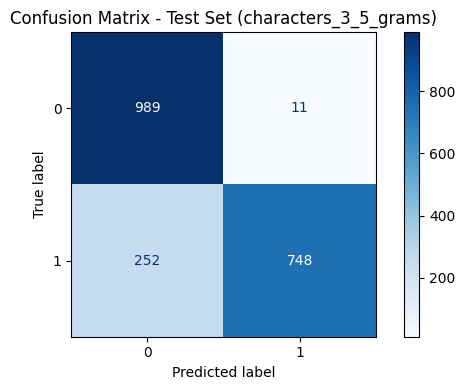

In [5]:
# Initialize the optimal pipeline
best_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer=best_params["analyzer"], 
        ngram_range=best_params["ngram_range"], 
        min_df=5
    )),
    ("clf", LinearSVC(C=1.0, random_state=42, dual=False, max_iter=2000))
])

# Train on the training set using the best column
best_column = best_params["column"]
best_pipeline.fit(df_train[best_column], y_train)

# Predictions on the three splits
pred_train = best_pipeline.predict(df_train[best_column])
pred_val = best_pipeline.predict(df_val[best_column])
pred_test = best_pipeline.predict(df_test[best_column])

# Print the classification reports
print("\n=== Train Set Evaluation ===")
print(classification_report(y_train, pred_train, zero_division=0))

print("=== Validation Set Evaluation ===")
print(classification_report(y_val, pred_val, zero_division=0))

print("=== Test Set Evaluation ===")
print(classification_report(y_test, pred_test, zero_division=0))

# Generate the confusion matrix on the test set
cm = confusion_matrix(y_test, pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_pipeline.classes_)

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=0)
plt.title(f"Confusion Matrix - Test Set ({best_config_name})")
plt.tight_layout()
plt.show()

### ROC and PR curve 

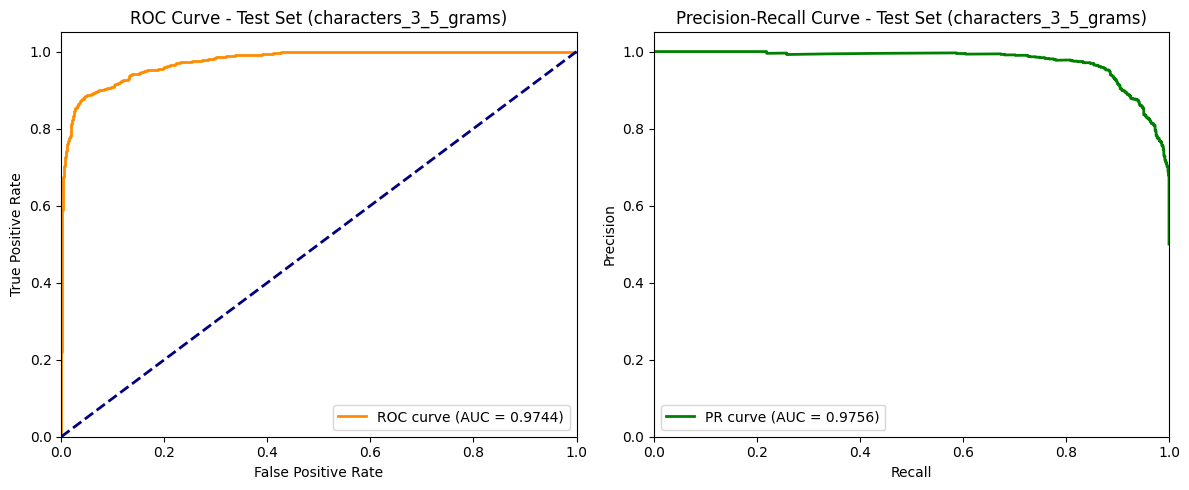

In [6]:
y_scores = best_pipeline.decision_function(df_test[best_column])

# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Receiver Operating Characteristic (ROC) Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal guessing line
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title(f'ROC Curve - Test Set ({best_config_name})')
ax1.legend(loc="lower right")

# Precision-Recall (PR) Curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_scores)
pr_auc = average_precision_score(y_test, y_scores)

ax2.plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title(f'Precision-Recall Curve - Test Set ({best_config_name})')
ax2.legend(loc="lower left")

# Adjust layout and display
plt.tight_layout()
plt.show()

### Overfitting Analysis (Train vs Validation)

To diagnose potential overfitting, the model's performance on the Training set is compared directly against the Validation set. This is assessed by calculating the Hinge Loss (the native cost function optimized by SVM) and the Macro-F1 score for both splits. A significant gap between the training and validation metrics indicates overfitting.


--- Overfitting Analysis: Training vs Validation ---


,Metric,Training,Validation,Gap (Val - Train),Gap (Train - Val)
0,Hinge Loss (Lower is better),0.0663,0.1678,0.1016,NaN
1,Macro-F1 (Higher is better),1.0000,0.9910,NaN,0.009



--- Interpretation ---
Good: The gap between Training and Validation scores is minimal.
The model generalizes well and does not show severe signs of overfitting.



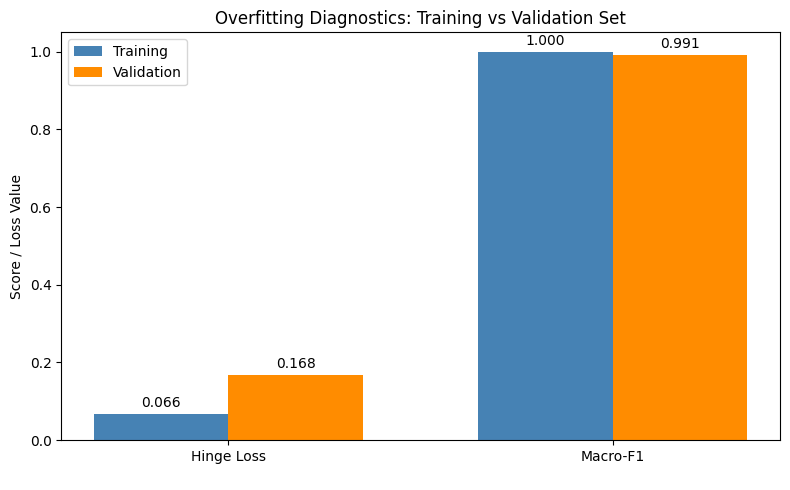

In [7]:
print("\n--- Overfitting Analysis: Training vs Validation ---")

# Extract the decision function scores
# Extract the decision function scores using the specific text column
dec_train = best_pipeline.decision_function(df_train[best_column])
dec_val = best_pipeline.decision_function(df_val[best_column])

# Hinge loss requires numeric targets {-1, 1}
# The classes are dynamically mapped based on the pipeline's detected classes
positive_class = best_pipeline.classes_[1]
y_train_num = np.where(y_train == positive_class, 1, -1)
y_val_num = np.where(y_val == positive_class, 1, -1)

# Calculate Hinge Loss
loss_train = hinge_loss(y_train_num, dec_train)
loss_val = hinge_loss(y_val_num, dec_val)

# Calculate Macro-F1 Score
f1_train = f1_score(y_train, pred_train, average='macro')
f1_val = f1_score(y_val, pred_val, average='macro')

# Calculate the gap between sets
loss_gap = loss_val - loss_train
f1_gap = f1_train - f1_val

# Structure the results in a DataFrame for clean visualization
overfitting_data = [
    {"Metric": "Hinge Loss (Lower is better)", "Training": loss_train, "Validation": loss_val, "Gap (Val - Train)": loss_gap},
    {"Metric": "Macro-F1 (Higher is better)", "Training": f1_train, "Validation": f1_val, "Gap (Train - Val)": f1_gap}
]

df_overfitting = pd.DataFrame(overfitting_data)

# Round numeric columns for better readability
df_overfitting = df_overfitting.round(4)

# Display the formatted table
display(df_overfitting)

# Provide an automated interpretation based on the F1 Gap
print("\n--- Interpretation ---")
if f1_gap > 0.15:
    print("Warning: A significant gap between Training and Validation scores is detected (F1 Gap > 0.15).")
    print("This suggests the model might be overfitting the training data.")
elif f1_gap < -0.05:
    print("Notice: Validation score is notably higher than Training score. Check data distribution.")
else:
    print("Good: The gap between Training and Validation scores is minimal.")
    print("The model generalizes well and does not show severe signs of overfitting.\n")

# Graphical Visualization (Bar Chart)
metrics = ['Hinge Loss\n', 'Macro-F1\n']
train_scores = [loss_train, f1_train]
val_scores = [loss_val, f1_val]

x = np.arange(len(metrics)) 
width = 0.35  

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, train_scores, width, label='Training', color='steelblue')
rects2 = ax.bar(x + width/2, val_scores, width, label='Validation', color='darkorange')

ax.set_ylabel('Score / Loss Value')
ax.set_title('Overfitting Diagnostics: Training vs Validation Set')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')

plt.tight_layout()
plt.show()